1. Импорт библиотек и загрузка данных

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


2. Загрузка данных и первичный анализ

In [8]:
# Загружаем данные из файла heart.csv (он должен лежать в той же папке, что и ноутбук)
df = pd.read_csv('heart.csv')

print("Исходные данные (первые 5 строк):")
print(df.head())
print(f"\nРазмерность данных: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print("\nСтатистика по числовым признакам:")
print(df.describe())

Исходные данные (первые 5 строк):
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Размерность данных: (1025, 14)

Типы данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Статис

3. Создание категориального признака из числового (возраст → возрастная группа)

In [9]:
# Определяем функцию для разбивки возраста на категории
def age_category(age):
    if age < 45:
        return 'Young'      # молодой
    elif age < 55:
        return 'Middle'     # средний
    else:
        return 'Elderly'    # пожилой

# Создаём новый столбец
df['Age_Category'] = df['age'].apply(age_category)

print("Первые 10 строк с новым категориальным признаком:")
print(df[['age', 'Age_Category']].head(10))
print("\nРаспределение категорий:")
print(df['Age_Category'].value_counts())

Первые 10 строк с новым категориальным признаком:
   age Age_Category
0   52       Middle
1   53       Middle
2   70      Elderly
3   61      Elderly
4   62      Elderly
5   58      Elderly
6   58      Elderly
7   55      Elderly
8   46       Middle
9   54       Middle

Распределение категорий:
Age_Category
Elderly    549
Middle     288
Young      188
Name: count, dtype: int64


4. Масштабирование одного числового признака (уровень холестерина – chol) с помощью StandardScaler

In [10]:
# Выбираем признак для масштабирования
feature_to_scale = 'chol'

# Инициализируем стандартизатор
scaler = StandardScaler()

# Масштабируем (fit_transform) и сохраняем в новый столбец
df['chol_scaled'] = scaler.fit_transform(df[[feature_to_scale]])

print(f"Исходный признак '{feature_to_scale}':")
print(f"  Среднее = {df[feature_to_scale].mean():.2f}, Стандартное отклонение = {df[feature_to_scale].std():.2f}")
print(f"Масштабированный признак 'chol_scaled':")
print(f"  Среднее = {df['chol_scaled'].mean():.2e}, Стандартное отклонение = {df['chol_scaled'].std():.2f}")

Исходный признак 'chol':
  Среднее = 246.00, Стандартное отклонение = 51.59
Масштабированный признак 'chol_scaled':
  Среднее = -3.47e-18, Стандартное отклонение = 1.00


5. Преобразование категориального признака в количественный – способ 1: Label Encoding

In [11]:
cat_col = 'Age_Category'

# Используем LabelEncoder
le = LabelEncoder()
df['Age_Category_LE'] = le.fit_transform(df[cat_col])

print("Способ 1: Label Encoding")
print(f"Соответствие категорий числам: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\nПервые 10 строк с закодированным признаком:")
print(df[[cat_col, 'Age_Category_LE']].head(10))

Способ 1: Label Encoding
Соответствие категорий числам: {'Elderly': np.int64(0), 'Middle': np.int64(1), 'Young': np.int64(2)}

Первые 10 строк с закодированным признаком:
  Age_Category  Age_Category_LE
0       Middle                1
1       Middle                1
2      Elderly                0
3      Elderly                0
4      Elderly                0
5      Elderly                0
6      Elderly                0
7      Elderly                0
8       Middle                1
9       Middle                1


6. Преобразование категориального признака – способ 2: One‑Hot Encoding

In [12]:
# Используем OneHotEncoder (sparse_output=False для получения обычного массива)
ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(df[[cat_col]])

# Получаем названия новых столбцов
ohe_cols = ohe.get_feature_names_out([cat_col])

# Создаём DataFrame с фиктивными переменными
df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)

print("Способ 2: One‑Hot Encoding")
print("Первые 10 строк полученных бинарных столбцов:")
print(df_ohe.head(10))

# (Опционально) можно объединить с исходным df, но для наглядности оставляем отдельно
# df = pd.concat([df, df_ohe], axis=1)

Способ 2: One‑Hot Encoding
Первые 10 строк полученных бинарных столбцов:
   Age_Category_Elderly  Age_Category_Middle  Age_Category_Young
0                   0.0                  1.0                 0.0
1                   0.0                  1.0                 0.0
2                   1.0                  0.0                 0.0
3                   1.0                  0.0                 0.0
4                   1.0                  0.0                 0.0
5                   1.0                  0.0                 0.0
6                   1.0                  0.0                 0.0
7                   1.0                  0.0                 0.0
8                   0.0                  1.0                 0.0
9                   0.0                  1.0                 0.0


7. Сравнение и обоснование выбранных методов

In [13]:
print("""
Обоснование выбора методов:
----------------------------
1. Масштабирование (StandardScaler):
   - Используем для признака 'chol', так как стандартизация приводит данные к 
     нулевому среднему и единичному стандартному отклонению.
   - Это необходимо для алгоритмов, чувствительных к масштабу (логистическая регрессия, 
     SVM, градиентный спуск), и помогает избежать доминирования признаков с большими 
     значениями.

2. Label Encoding:
   - Применён к категориальному признаку 'Age_Category', который имеет естественный 
     порядок (Young < Middle < Elderly).
   - Присвоение чисел 0,1,2 сохраняет этот порядок, что может быть полезно для 
     деревьев решений и некоторых линейных моделей.
   - Компактный способ, не создающий лишних столбцов.

3. One‑Hot Encoding:
   - Показан как альтернативный метод для ситуаций, когда категории не имеют порядка 
     (номинальные признаки).
   - Создаёт бинарные столбцы для каждой категории, исключая ложную порядковую 
     зависимость.
   - В нашем случае, поскольку порядок есть, Label Encoding более предпочтителен, 
     но One‑Hot продемонстрирован для полноты.
""")


Обоснование выбора методов:
----------------------------
1. Масштабирование (StandardScaler):
   - Используем для признака 'chol', так как стандартизация приводит данные к 
     нулевому среднему и единичному стандартному отклонению.
   - Это необходимо для алгоритмов, чувствительных к масштабу (логистическая регрессия, 
     SVM, градиентный спуск), и помогает избежать доминирования признаков с большими 
     значениями.

2. Label Encoding:
   - Применён к категориальному признаку 'Age_Category', который имеет естественный 
     порядок (Young < Middle < Elderly).
   - Присвоение чисел 0,1,2 сохраняет этот порядок, что может быть полезно для 
     деревьев решений и некоторых линейных моделей.
   - Компактный способ, не создающий лишних столбцов.

3. One‑Hot Encoding:
   - Показан как альтернативный метод для ситуаций, когда категории не имеют порядка 
     (номинальные признаки).
   - Создаёт бинарные столбцы для каждой категории, исключая ложную порядковую 
     зависимость.
   - В

8. Визуализация: диаграмма рассеяния (возраст vs холестерин) с окраской по целевому признаку

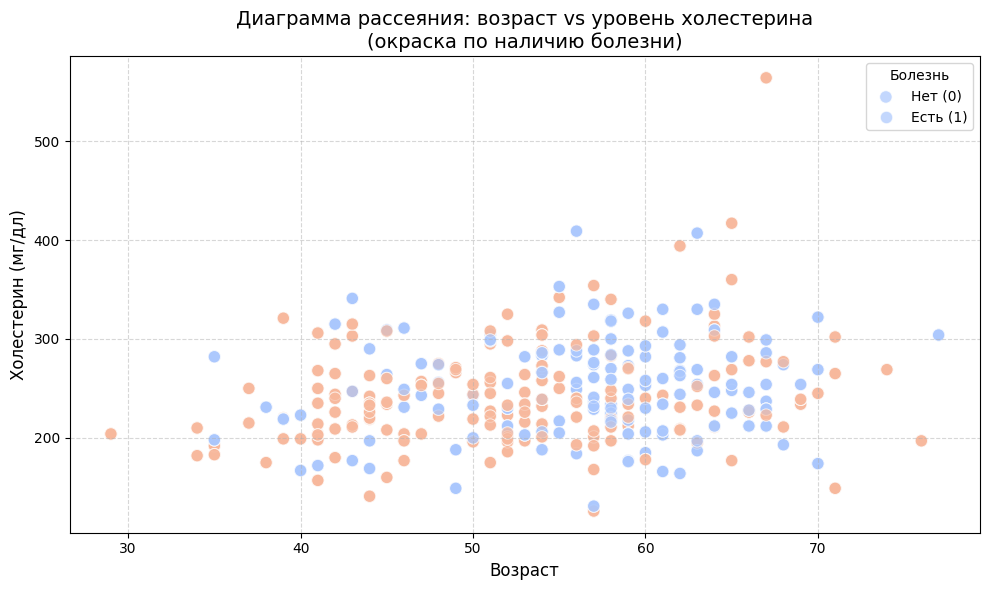

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='age', 
    y='chol', 
    hue='target', 
    palette='coolwarm', 
    s=80, 
    alpha=0.7
)
plt.title('Диаграмма рассеяния: возраст vs уровень холестерина\n(окраска по наличию болезни)', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Холестерин (мг/дл)', fontsize=12)
plt.legend(title='Болезнь', labels=['Нет (0)', 'Есть (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()